In [ ]:
!pip install sentence-transformers torch transformers

In [ ]:
import torch

# GPU가 연결되었는지 확인하는 코드
if torch.cuda.is_available():
    print(f"성공! 현재 사용 가능한 GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU 연결 실패... CPU 모드입니다.")

성공! 현재 사용 가능한 GPU: Tesla T4


In [ ]:
!pip install -U sentence-transformers

In [ ]:
import pandas as pd
import pickle

df = pd.read_csv("/content/drive/MyDrive/DX PROJ./층간소음데이터통합_영어제거완료.csv")

In [ ]:
df

,제목,본문,token
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']"
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']"
2,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'..."
3,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"['아파트', '층간소음', '불만', '충', '나무', '아파트', '강제', ..."
4,NaN,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"['정신병', '이웃', '난', '불다', '조현병', '같다', '두다']"
...,...,...,...
58618,13층 미친 것들,층간소음충들은 왜 잠도 안 자고 밖에 나가지도 않고 맨날 집구석에서 지랄들일까요 5...,"['층간소음', '충', '왜', '잠도', '안', '자고', '나가다', '않다..."
58619,아니 발 모가지 분질러야되나요,매일 이 늦은 시간에 워킹패드하는지 층간소음층간소음 웈웈웈웅 하 윗집인지 웟윗집인지...,"['매일', '늦다', '시간', '워킹', '패드', '하다', '층간소음', '..."
58620,층간소음 일지&증거 민사+관리사무소+이웃사이센터,혹시 층간소음 일지 및 동영상으로 민사를 준비하고 있는데 소음일지 작성 동영상 증거...,"['혹시', '층간소음', '일지', '및', '동영상', '민사', '준비', '..."
58621,이것들은왜 외출도안하나요,주말인데도 외출하는꼴을못보네 아오 집에서 시끄러우면 자주나가기라도해라,"['주말', '외출', '하다', '꼴다', '보다', '집', '시끄럽다', '자..."


In [ ]:
# 1. '통합본문'이 NaN인 행들만 필터링하여 새로운 변수에 담습니다.
nan_rows = df[df['본문'].isna()]

# 2. 결측치 행의 개수를 출력합니다.
print(f"현재 '본문'이 비어있는 행의 개수: {len(nan_rows)}개")

# 3. 결측치 행들을 화면에 출력합니다.
# 데이터가 많을 수 있으니 상위 10개 정도만 먼저 확인해 보세요.
nan_rows.head(10)

현재 '본문'이 비어있는 행의 개수: 57개


,제목,본문,token
23102,NaN,NaN,[]
25584,대포소리,NaN,[]
26138,펑,NaN,[]
26452,매번 지랄. 살날리고싶어집니다,NaN,[]
27094,카페에서 훈계하는 사람이 생겼네요,NaN,[]
27216,이사갑니다.. 원룸 둘 중 어디가 나을까요,NaN,[]
27285,하루종일 뛰어다닙니다.,NaN,[]
27293,13층 객사 비명횡사 기원 1일차,NaN,[]
27817,계속 천장에서 우우우웅 하는 진동이 계속 들립니다.. 진짜 뭘까요,NaN,[]
27936,바퀴벌레들 움직일 시간입니다,NaN,[]


In [ ]:
# 1. '통합본문' 컬럼에 결측치가 있는 행을 제거합니다.
df = df.dropna(subset=['본문'])

In [ ]:
df

,제목,본문,token
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']"
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']"
2,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'..."
3,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"['아파트', '층간소음', '불만', '충', '나무', '아파트', '강제', ..."
4,NaN,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"['정신병', '이웃', '난', '불다', '조현병', '같다', '두다']"
...,...,...,...
58618,13층 미친 것들,층간소음충들은 왜 잠도 안 자고 밖에 나가지도 않고 맨날 집구석에서 지랄들일까요 5...,"['층간소음', '충', '왜', '잠도', '안', '자고', '나가다', '않다..."
58619,아니 발 모가지 분질러야되나요,매일 이 늦은 시간에 워킹패드하는지 층간소음층간소음 웈웈웈웅 하 윗집인지 웟윗집인지...,"['매일', '늦다', '시간', '워킹', '패드', '하다', '층간소음', '..."
58620,층간소음 일지&증거 민사+관리사무소+이웃사이센터,혹시 층간소음 일지 및 동영상으로 민사를 준비하고 있는데 소음일지 작성 동영상 증거...,"['혹시', '층간소음', '일지', '및', '동영상', '민사', '준비', '..."
58621,이것들은왜 외출도안하나요,주말인데도 외출하는꼴을못보네 아오 집에서 시끄러우면 자주나가기라도해라,"['주말', '외출', '하다', '꼴다', '보다', '집', '시끄럽다', '자..."


In [ ]:
df = df.drop(columns=['제목'])
display(df.head())

,본문,token
0,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']"
1,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']"
2,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'..."
3,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"['아파트', '층간소음', '불만', '충', '나무', '아파트', '강제', ..."
4,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"['정신병', '이웃', '난', '불다', '조현병', '같다', '두다']"


# 임베딩 및 결측치 제거 : 임베딩 해야할 열은 '본문'

In [ ]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('jhgan/ko-sroberta-multitask')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# 1. '통합본문' 컬럼에 결측치가 있는 행을 제거합니다.
df = df.dropna(subset=['본문'])

# 2. (혹시 모르니) 모든 데이터를 문자열 타입으로 확실히 변환합니다.
text_list = df['본문'].astype(str).tolist()

# 3. 다시 임베딩을 진행합니다.
print(f"총 {len(text_list)}개의 문장을 임베딩합니다...")
embeddings = model.encode(text_list, show_progress_bar=True)

# 4. 결과 확인
print("임베딩 완료! 형태:", embeddings.shape)

총 58566개의 문장을 임베딩합니다...


Batches:   0%|          | 0/1831 [00:00<?, ?it/s]

임베딩 완료! 형태: (58566, 768)


In [ ]:
df.to_pickle('KosentenceBERT_최종.pkl')

# sampling -> K-means

In [ ]:
from sklearn.cluster import MiniBatchKMeans
import numpy as np

# 1. 데이터를 1,000개의 대표점으로 요약합니다.
# n_clusters를 1000으로 설정합니다. (더 자세히 보고 싶다면 2000도 좋습니다.)
n_representative_points = 2000
kmeans_proxy = MiniBatchKMeans(n_clusters=n_representative_points, random_state=42, batch_size=2048)
kmeans_proxy.fit(embeddings)

# 2. 1,000개의 대표점 좌표(Centroids)를 추출합니다.
# 이제 이 'centroids'가 5만 개 데이터의 특징을 대변하는 요약본이 됩니다.
centroids = kmeans_proxy.cluster_centers_

print(f"압축 완료: {embeddings.shape[0]}개 데이터 -> {centroids.shape[0]}개 대표점")

압축 완료: 58566개 데이터 -> 2000개 대표점


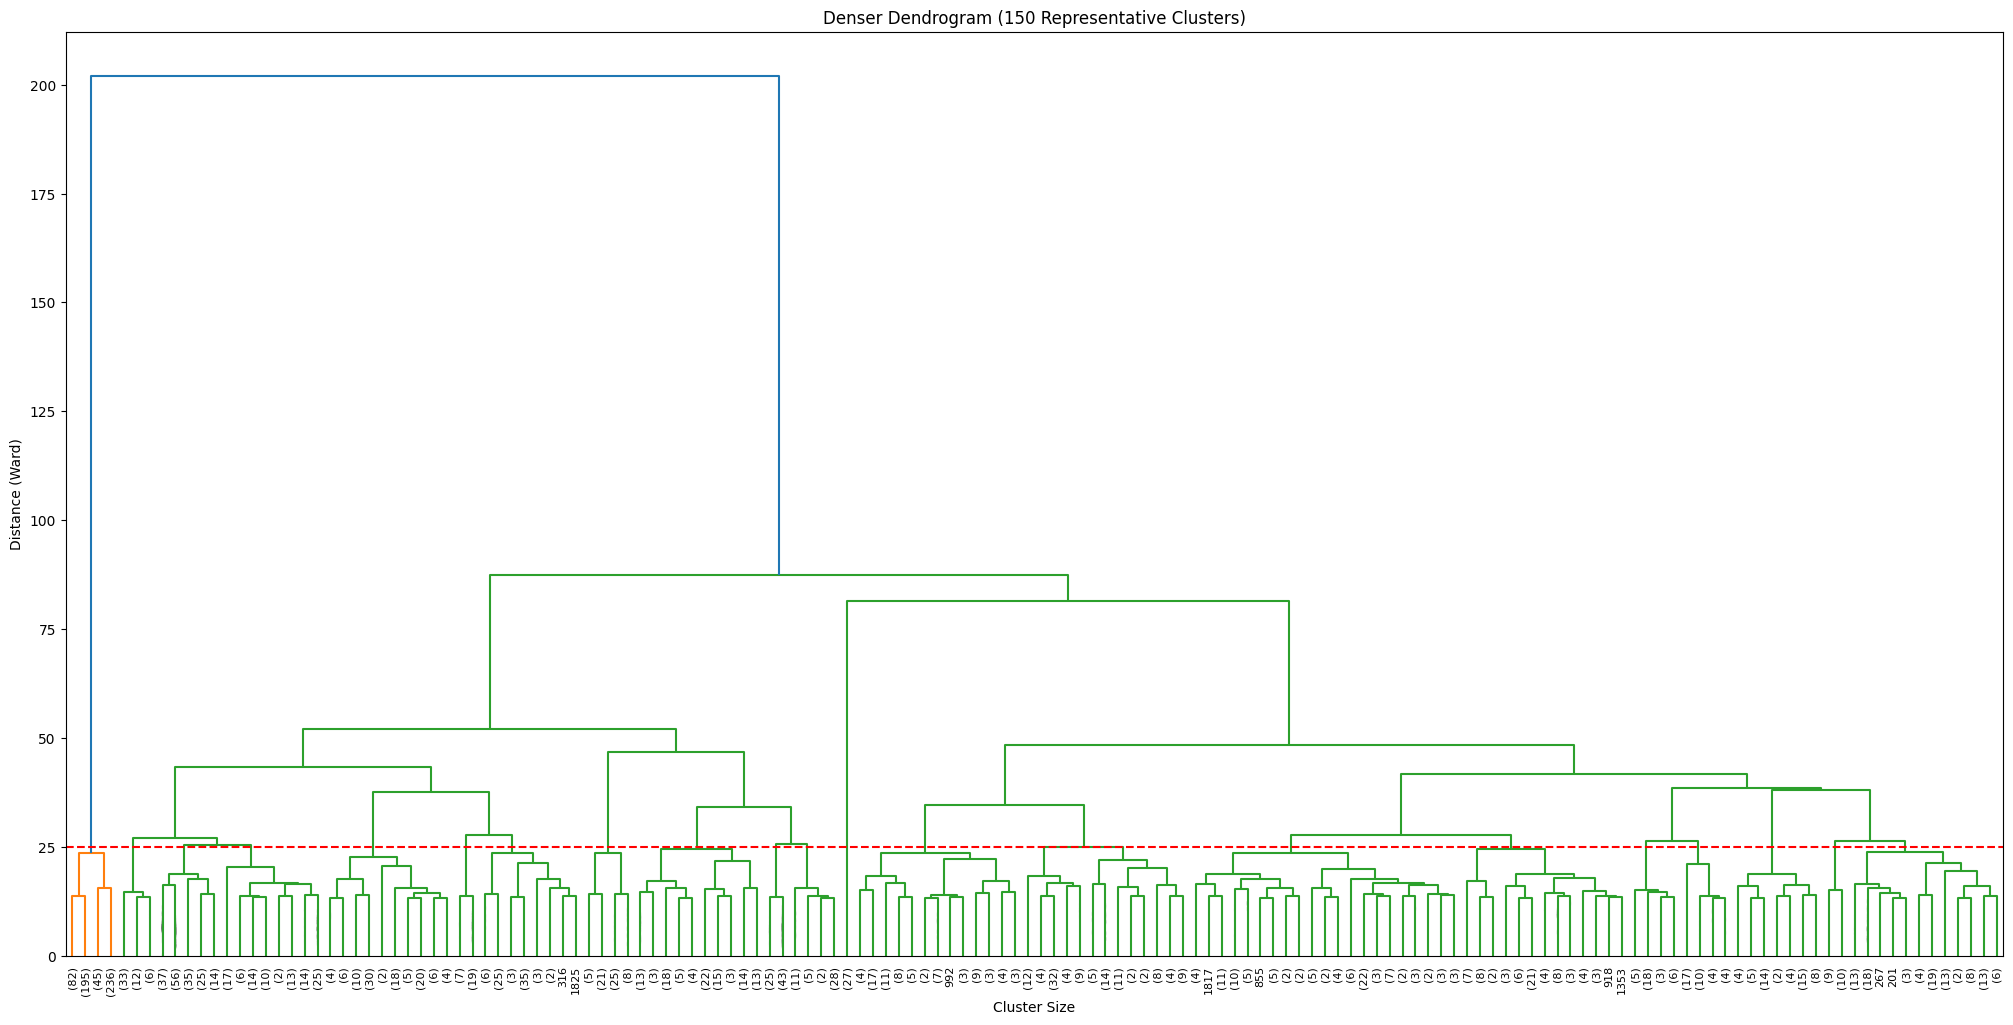

In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# 1. [누락되었던 핵심 코드] 대표점(centroids)을 이용해 연결 행렬 생성
# 군집 내 분산을 최소화하는 'ward' 연결 방식을 사용합니다.
linkage_matrix = sch.linkage(centroids, method='ward')

# 2. 덴드로그램 시각화 (작성하셨던 코드 그대로 사용)
plt.figure(figsize=(25, 12))

dendrogram = sch.dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=150,
    leaf_rotation=90.,
    leaf_font_size=8.,
    show_contracted=True
)

plt.title('Denser Dendrogram (150 Representative Clusters)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance (Ward)')


plt.show()

# 최적의 클러스터 갯수 찾기 - 실루엣 분석

실루엣 점수 계산 시작 (대표점 1,000개 기준)...
군집 수(k): 2, 실루엣 점수: 0.2093
군집 수(k): 3, 실루엣 점수: 0.2139
군집 수(k): 4, 실루엣 점수: 0.2287
군집 수(k): 5, 실루엣 점수: 0.2305
군집 수(k): 6, 실루엣 점수: 0.2067
군집 수(k): 7, 실루엣 점수: 0.2070
군집 수(k): 8, 실루엣 점수: 0.2037
군집 수(k): 9, 실루엣 점수: 0.2051
군집 수(k): 10, 실루엣 점수: 0.2032


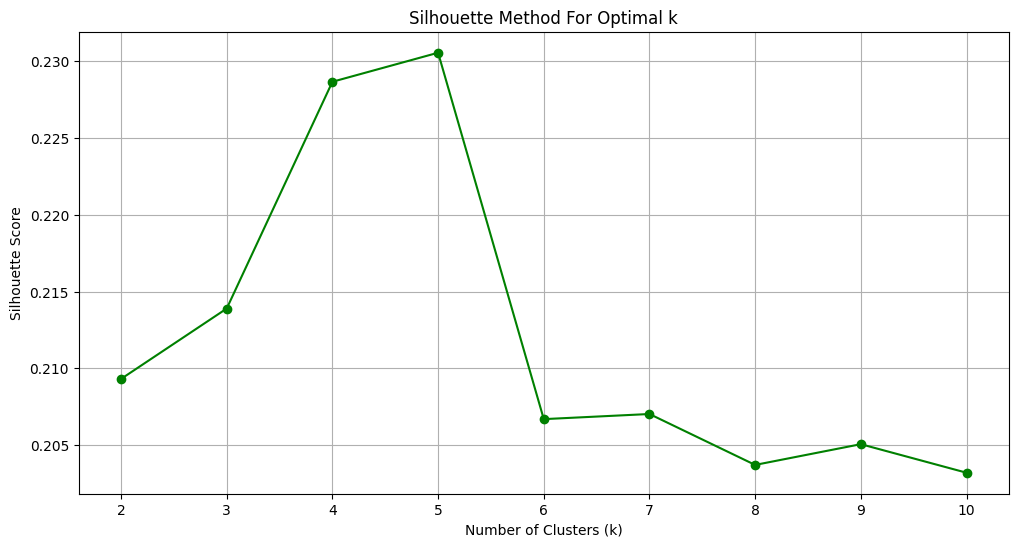

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. 테스트할 군집 개수 범위 설정 (예: 2개부터 20개까지)
k_range = range(2, 11)
silhouette_avg = []

print("실루엣 점수 계산 시작 (대표점 1,000개 기준)...")

for k in k_range:
    # KMeans 모델 생성 및 학습 (대표점인 centroids 활용)
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(centroids)

    # 실루엣 점수 계산
    score = silhouette_score(centroids, cluster_labels)
    silhouette_avg.append(score)
    print(f"군집 수(k): {k}, 실루엣 점수: {score:.4f}")

# 2. 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(k_range, silhouette_avg, 'go-') # 녹색 점선 그래프
plt.title('Silhouette Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range) # x축 간격을 1단위로 표시
plt.grid(True)
plt.show()

# clustering

In [ ]:
from sklearn.cluster import KMeans

# 1. k=4로 클러스터링 실행
kmeans4 = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['cluster_k5'] = kmeans4.fit_predict(embeddings)

In [ ]:
print("--- [k=5] 군집별 분포 ---")
print(df['cluster_k5'].value_counts().sort_index())

--- [k=5] 군집별 분포 ---
cluster_k5
0     7687
1    14997
2    10838
3    14209
4    10835
Name: count, dtype: int64


In [ ]:
def check_cluster_samples(df, cluster_col, n_samples=5):
    clusters = sorted(df[cluster_col].unique())
    for c in clusters:
        print(f"\n{'='*20} {cluster_col} - Cluster {c} {'='*20}")
        # 해당 군집에서 샘플 추출
        samples = df[df[cluster_col] == c]['본문'].sample(n_samples, random_state=42)
        for i, text in enumerate(samples):
            print(f"[{i+1}] {text[:150]}...") # 내용을 150자까지 확인

# k=4 결과 먼저 확인하기
check_cluster_samples(df, 'cluster_k5')


==================== cluster_k5 - Cluster 0 ====================
[1] 완전 범죄 니짜쎄쎄 마피아 조직같네요 이러니 일반 사람들이 힘든 나라꼬라지입니다...
[2] 6세남아 4세여아 발목을 도끼로 찍어서 끊어죽여버리고 싶은 새끼들 부모들이 전혀 제지하지않는 끊임없는 층간소음 달리기시합 소리 죽여버리고싶습니다 당장 망치로 발목 찍어죽이고 싶네요 끔찍한인간들 어떻게 조져야할까요 관리사무소 인터폰도 안받고 층간소음층간소음 발꿈치 자르고...
[3] 층간소음 쪽지 명예훼손으로 고소 가능해 궁금하네 아 아래는 내가 층간소음 항의한 글에 와서 시비건 아줌마얌 다른형이 저거 보여주닌깐 글 다 삭제하고 도망 갔더라고...
[4] 층간소음의 제일 엿같은 점은 가해자들의 처분만을 바래야한다는 것 그들이 뛰면 극도의 스트레스를 받다가 몇 시간 혹은 몇 일 조용하면 안도하고 살만해지는 내 기분 컨디션 그 날의 감정이 가해자 손에 달렸다는게 제일 엿같다...
[5] 공동 공간에 들어오면 당연히 조용히 살고 조심하는 기본 상식인 거지 개소리임 남들 공간에서 조심하기 싫은 새끼들이 공용 공간에 살면 되고 나가서 혼자 살라고 미친 소리를 보겠네 제정신인가...

==================== cluster_k5 - Cluster 1 ====================
[1] 아파트가 이렇게 부실해도 되나요 게시판 안내를 확인해 주세요 상호간의 예의 공지사항 1007 카페 회원으로서 쾌적한 카페가 되기 위하여 아래의 사항을 꼭 지켜 주시기 바랍니다 1 카페 회원을 비방하는 행위 2 회원에 대한 인신 공격적 모독 행위 3 회원에 대하여 욕설을...
[2] 꽤 오래 참다가 어제 저녁에 민원을 넣었는데요 게시판 안내를 확인해 주세요 상호간의 예의 공지사항 1007 카페 회원으로서 쾌적한 카페가 되기 위하여 아래의 사항을 꼭 지켜 주시기 바랍니다 1 카페 회원을 비방하는 행위 2 회원에 대한 인신 공격적 모독 행위 3 회원에...
[3

In [ ]:
df['cluster_k5'].value_counts()

,count
cluster_k5,
1,14997
3,14209
2,10838
4,10835
0,7687


In [ ]:
# 1. 군집별로 텍스트를 합칩니다.
cluster_docs = df.groupby('cluster_k5')['본문'].apply(lambda x: ' '.join(x)).reset_index()

# 확인: cluster_docs는 4개의 행(0~3번 군집)을 가집니다.
print(cluster_docs.head())

   cluster_k5                                                 본문
0           0  정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야 인간이길 포기한 숨쉬며 꿈틀...
1           1  허위 광고예요 층소 관련 카페에서 쓰고 추천한다는 사람 사람밖에 봤고 층소 동영상마...
2           2  현대가 지은 아파트 아니나 확인 해봐라 철근 먹었나 조사해보고 저래서 요즘은 엘베 ...
3           3  엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요 서대구역 구역 이라고...
4           4  가족들 그엘베 타는거 고역이겠다 어떻게 사냐 정신병자네요 아래집 인간 살면 답없음 ...


In [ ]:
df.to_pickle('KosentenceBERT_최종_클러스터 5개로.pkl')

In [ ]:
import pickle

with open("KosentenceBERT_최종_클러스터 5개로.pkl", "rb") as file:
    df = pickle.load(file)

df.head()

,본문,token,cluster_k5
0,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']",4
1,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']",3
2,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'...",3
3,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"['아파트', '층간소음', '불만', '충', '나무', '아파트', '강제', ...",3
4,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"['정신병', '이웃', '난', '불다', '조현병', '같다', '두다']",0


In [ ]:
# 1. 군집별로 텍스트를 합칩니다.
cluster_docs = df.groupby('cluster_k5')['본문'].apply(lambda x: ' '.join(x)).reset_index()

# 확인: cluster_docs는 4개의 행(0~3번 군집)을 가집니다.
print(cluster_docs.head())

   cluster_k5                                                 본문
0           0  정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야 인간이길 포기한 숨쉬며 꿈틀...
1           1  허위 광고예요 층소 관련 카페에서 쓰고 추천한다는 사람 사람밖에 봤고 층소 동영상마...
2           2  현대가 지은 아파트 아니나 확인 해봐라 철근 먹었나 조사해보고 저래서 요즘은 엘베 ...
3           3  엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요 서대구역 구역 이라고...
4           4  가족들 그엘베 타는거 고역이겠다 어떻게 사냐 정신병자네요 아래집 인간 살면 답없음 ...


# tf-idf

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 2. TF-IDF 계산
# stop_words에 불필요한 단어(예: '진짜', '너무', '해요')를 추가하면 더 정확합니다.
tfidf = TfidfVectorizer(max_features=20) # 군집당 상위 20개 단어만 추출
tfidf_matrix = tfidf.fit_transform(cluster_docs['본문'])

# 단어 목록 가져오기
words = tfidf.get_feature_names_out()

In [ ]:
import pandas as pd

# 3. 각 군집별 상위 키워드 출력
importance = tfidf_matrix.toarray()

for i in range(4):
    # i번째 군집의 TF-IDF 점수가 높은 상위 10개 단어 인덱스 추출
    top_indices = importance[i].argsort()[-50:][::-1]
    top_keywords = [words[idx] for idx in top_indices]

    print(f"\n[Cluster {i}] 핵심 키워드:")
    print(", ".join(top_keywords))


[Cluster 0] 핵심 키워드:
하는, 없이, 대한, 바랍니다, 주세요, 예의, 카페, 보기, 경고, 행위, 위반, 되기, 하겠습니다, 사용하는, 아래의, 확인해, 회원에, 카페가, 욕설을, 사항을

[Cluster 1] 핵심 키워드:
회원에, 행위, 욕설을, 사항을, 하는, 카페, 카페가, 없이, 대한, 바랍니다, 주세요, 사용하는, 경고, 하겠습니다, 되기, 보기, 확인해, 예의, 아래의, 위반

[Cluster 2] 핵심 키워드:
하는, 없이, 주세요, 바랍니다, 대한, 사용하는, 카페, 하겠습니다, 보기, 확인해, 되기, 사항을, 아래의, 예의, 위반, 행위, 경고, 회원에, 욕설을, 카페가

[Cluster 3] 핵심 키워드:
하는, 없이, 대한, 주세요, 카페, 바랍니다, 사용하는, 경고, 욕설을, 행위, 보기, 하겠습니다, 예의, 확인해, 카페가, 되기, 사항을, 위반, 아래의, 회원에


In [ ]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 34.5 MB/s eta 0:00:00


# 단어 추출

In [ ]:
from konlpy.tag import Okt
import pandas as pd
from tqdm import tqdm

# 1. 형태소 분석기 초기화
okt = Okt()

# 2. 명사 추출 함수 정의
def extract_nouns(text):
    if not isinstance(text, str):
        return ""
    # 명사만 추출
    nouns = okt.nouns(text)
    # 한 글자 단어 제외 및 불용어 필터링 (필요시 추가)
    nouns = [n for n in nouns if len(n) > 1]
    return " ".join(nouns)

# 3. tqdm을 사용하여 진행률 확인하며 명사 추출 실행
# 데이터가 많으므로 apply 대신 리스트 컴프리헨션 + tqdm 조합을 권장합니다.
tqdm.pandas()
df['extracted_nouns'] = df['본문'].progress_apply(extract_nouns)

# 4. 결과 확인 (제대로 추출됐는지 상위 5개만 확인)
print(df[['본문', 'extracted_nouns']].head())

100%|██████████| 58566/58566 [11:02<00:00, 88.45it/s] 

                                                  본문  \
0                           가족들 그엘베 타는거 고역이겠다 어떻게 사냐   
1                 엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요   
2  서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...   
3            아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다   
4                     정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야   

             extracted_nouns  
0                   가족 엘베 고역  
1                엘베 층간소음 세탁기  
2    서대구역 구역 단지 부실 공사 평가 아파트  
3  아파트 층간소음 불만 나무 아파트 강제 만듭시  
4                 정신병 이웃 조현병  


In [ ]:
# 1. 군집별로 추출된 명사들을 합칩니다.
cluster_docs = df.groupby('cluster_k5')['extracted_nouns'].apply(lambda x: ' '.join(x)).reset_index()

# 2. TF-IDF 계산
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=50) # 상위 50개까지 확인
tfidf_matrix = tfidf.fit_transform(cluster_docs['extracted_nouns'])
words = tfidf.get_feature_names_out()
importance = tfidf_matrix.toarray()

# 3. 결과 출력
for i in range(5):
    top_indices = importance[i].argsort()[-20:][::-1]
    top_keywords = [words[idx] for idx in top_indices]
    print(f"\n[Cluster {i}] 핵심 키워드: {', '.join(top_keywords)}")


[Cluster 0] 핵심 키워드: 사람, 층간소음, 아이, 생각, 소음, 소리, 진짜, 정도, 관리, 그냥, 지금, 우리, 스트레스, 때문, 시간, 사무소, 망치, 거리, 계속, 아파트

[Cluster 1] 핵심 키워드: 회원, 행위, 카페, 사항, 욕설, 소리, 인신, 비방, 모독, 강퇴, 확인, 아래, 사용, 공격, 대한, 보기, 안내, 예의, 경고, 시기

[Cluster 2] 핵심 키워드: 소리, 사람, 아이, 소음, 생각, 정도, 시간, 사용, 층간소음, 지금, 진짜, 그냥, 오늘, 우리, 때문, 거리, 계속, 관리, 이사, 망치

[Cluster 3] 핵심 키워드: 층간소음, 소리, 소음, 아이, 사람, 관리, 아파트, 사무소, 이사, 진짜, 정도, 생각, 새벽, 시간, 우리, 저희, 지금, 스트레스, 계속, 때문

[Cluster 4] 핵심 키워드: 소리, 층간소음, 아이, 소음, 진짜, 새벽, 시간, 사람, 오늘, 스트레스, 생각, 계속, 지금, 정도, 아침, 거리, 관리, 그냥, 사무소, 때문


In [ ]:
top_n = 30
cluster_dict = {}

for i in range(len(cluster_docs)):
    # 해당 군집에서 TF-IDF 점수가 높은 상위 30개 인덱스 추출
    top_indices = importance[i].argsort()[-top_n:][::-1]
    cluster_dict[f'Cluster {i}'] = [words[idx] for idx in top_indices]

# 4. 딕셔너리를 데이터프레임으로 변환
keywords_df = pd.DataFrame(cluster_dict)

# 결과 확인
print("--- 군집별 상위 30개 핵심 키워드 ---")
display(keywords_df)

--- 군집별 상위 30개 핵심 키워드 ---


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
0,사람,회원,소리,층간소음,소리
1,층간소음,행위,사람,소리,층간소음
2,아이,카페,아이,소음,아이
3,생각,사항,소음,아이,소음
4,소음,욕설,생각,사람,진짜
5,소리,소리,정도,관리,새벽
6,진짜,인신,시간,아파트,시간
7,정도,비방,사용,사무소,사람
8,관리,모독,층간소음,이사,오늘
9,그냥,강퇴,지금,진짜,스트레스


# ratio

In [ ]:
# 각 군집별 단어와 점수를 합친 데이터프레임 생성
summary_list = []

for i in range(len(cluster_docs)):
    top_indices = importance[i].argsort()[-30:][::-1]
    for rank, idx in enumerate(top_indices):
        summary_list.append({
            'Cluster': f'Cluster {i}',
            'Rank': rank + 1,
            'Keyword': words[idx],
            'Score': round(importance[i][idx], 4)
        })

# 보기 편하게 피벗 테이블 형태로 변환하거나 긴 형태로 유지
ranking_df = pd.DataFrame(summary_list)
ranking_df_pivot = ranking_df.pivot(index='Rank', columns='Cluster', values=['Keyword', 'Score'])

# 상위 15개 확인
display(ranking_df_pivot.head(15))

Keyword                                             Score            \
Cluster Cluster 0 Cluster 1 Cluster 2 Cluster 3 Cluster 4 Cluster 0 Cluster 1   
Rank                                                                            
1              사람        회원        소리      층간소음        소리    0.6619    0.5112   
2            층간소음        행위        사람        소리      층간소음    0.3825    0.4087   
3              아이        카페        아이        소음        아이    0.3346    0.3122   
4              생각        사항        소음        아이        소음     0.263    0.3062   
5              소음        욕설        생각        사람        진짜    0.2565    0.2421   
6              소리        소리        정도        관리        새벽    0.2477    0.1806   
7              진짜        인신        시간       아파트        시간    0.1532    0.1727   
8              정도        비방        사용       사무소        사람    0.1092    0.1434   
9              관리        모독      층간소음        이사        오늘    0.0928    0.1434   
10             그냥        강퇴        지금        진짜      스트레스    0.0872    0.1434   
11             지금        확인        진짜        정도        생각    0.0842    0.1087   
12             우리        아래        그냥        생각        계속    0.0837    0.1075   
13           스트레스        사용        오늘        새벽        지금    0.0816    0.1056   
14             때문        공격        우리        시간        정도    0.0769    0.1041   
15             시간        대한        때문        우리        아침    0.0696    0.1035   

                                       
Cluster Cluster 2 Cluster 3 Cluster 4  
Rank                                   
1          0.6557    0.6281    0.6458  
2          0.3589    0.5218    0.4227  
3          0.2976    0.3022    0.3522  
4          0.2687    0.2374    0.2322  
5          0.2576    0.1545    0.1974  
6          0.1704    0.1423    0.1841  
7          0.1674    0.1376    0.1526  
8          0.1509     0.128    0.1445  
9          0.1489    0.1234     0.111  
10         0.1426    0.1165    0.1091  
11         0.1327       0.1    0.1037  
12          0.116    0.0977    0.1018  
13         0.1008    0.0889    0.0974  
14         0.0957    0.0805    0.0969  
15         0.0881    0.0789    0.0904

In [ ]:
import pandas as pd

# 1. 상위 30개 단어와 점수를 나란히 저장할 리스트 생성
top_n = 30
interleaved_data = {}

for i in range(len(cluster_docs)):
    # 해당 군집의 점수 높은 순으로 인덱스 추출
    top_indices = importance[i].argsort()[-top_n:][::-1]

    # 단어와 점수 컬럼을 각각 생성하여 저장
    interleaved_data[f'Cluster {i} Keyword'] = [words[idx] for idx in top_indices]
    interleaved_data[f'Cluster {i} Score'] = [round(importance[i][idx], 4) for idx in top_indices]

# 2. 데이터프레임 생성
final_keywords_score_df = pd.DataFrame(interleaved_data)

# 3. 인덱스를 Rank(순위)로 변경 (보기 편하게 1부터 시작)
final_keywords_score_df.index = [f'{i+1}위' for i in range(top_n)]

# 4. 결과 출력 및 파일 저장
print("--- [최종] 군집별 키워드 및 c-TF-IDF 점수 ---")
final_keywords_score_df.to_csv('cluster_keyword_scores_final.csv', encoding='utf-8-sig')
display(final_keywords_score_df)

--- [최종] 군집별 키워드 및 c-TF-IDF 점수 ---


,Cluster 0 Keyword,Cluster 0 Score,Cluster 1 Keyword,Cluster 1 Score,Cluster 2 Keyword,Cluster 2 Score,Cluster 3 Keyword,Cluster 3 Score,Cluster 4 Keyword,Cluster 4 Score
1위,사람,0.6619,회원,0.5112,소리,0.6557,층간소음,0.6281,소리,0.6458
2위,층간소음,0.3825,행위,0.4087,사람,0.3589,소리,0.5218,층간소음,0.4227
3위,아이,0.3346,카페,0.3122,아이,0.2976,소음,0.3022,아이,0.3522
4위,생각,0.2630,사항,0.3062,소음,0.2687,아이,0.2374,소음,0.2322
5위,소음,0.2565,욕설,0.2421,생각,0.2576,사람,0.1545,진짜,0.1974
6위,소리,0.2477,소리,0.1806,정도,0.1704,관리,0.1423,새벽,0.1841
7위,진짜,0.1532,인신,0.1727,시간,0.1674,아파트,0.1376,시간,0.1526
8위,정도,0.1092,비방,0.1434,사용,0.1509,사무소,0.1280,사람,0.1445
9위,관리,0.0928,모독,0.1434,층간소음,0.1489,이사,0.1234,오늘,0.1110
10위,그냥,0.0872,강퇴,0.1434,지금,0.1426,진짜,0.1165,스트레스,0.1091


# 공통단어 제거

In [ ]:
# 1. 제거하고 싶은 공통 단어 리스트 (이미지 결과를 보고 추가해 보세요)
custom_stopwords = [ '층간소음', '소음', '소리']

# 2. TfidfVectorizer 재설정
# max_df=0.75 : 4개 군집 중 3개 이상(75%)에서 공통으로 나오는 단어는 제외
tfidf = TfidfVectorizer(max_features=5000,
                        stop_words=custom_stopwords,
                        max_df=0.75)

tfidf_matrix = tfidf.fit_transform(cluster_docs['extracted_nouns'])
words = tfidf.get_feature_names_out()
importance = tfidf_matrix.toarray()

# 이후 동일하게 상위 30개 추출 및 데이터프레임 생성

In [ ]:
top_n = 10
interleaved_data = {}

for i in range(len(cluster_docs)):
    # 해당 군집의 점수 높은 순으로 인덱스 추출
    top_indices = importance[i].argsort()[-top_n:][::-1]

    # 단어와 점수 컬럼을 각각 생성하여 저장
    interleaved_data[f'Cluster {i} Keyword'] = [words[idx] for idx in top_indices]
    interleaved_data[f'Cluster {i} Score'] = [round(importance[i][idx], 4) for idx in top_indices]

# 4. 데이터프레임 생성 및 인덱스 설정
final_df = pd.DataFrame(interleaved_data)
final_df.index = [f'{i+1}위' for i in range(top_n)]

print("--- [최종] 정제된 군집별 키워드 및 영향력 점수 ---")
display(final_df) # 또는 print(final_df)

--- [최종] 정제된 군집별 키워드 및 영향력 점수 ---


,Cluster 0 Keyword,Cluster 0 Score,Cluster 1 Keyword,Cluster 1 Score,Cluster 2 Keyword,Cluster 2 Score,Cluster 3 Keyword,Cluster 3 Score,Cluster 4 Keyword,Cluster 4 Score
1위,보행자,0.2407,인신,0.5708,유닉스,0.2591,맨션,0.2132,티라미스,0.3225
2위,클락,0.2243,비방,0.4740,코난,0.2265,아래아,0.1435,영수,0.1810
3위,국회의원,0.2188,모독,0.4740,소크라테스,0.1917,복비,0.1353,영숙,0.1402
4위,무기징역,0.1696,강퇴,0.4739,포테토칩,0.1872,집임,0.1230,네시,0.1268
5위,민주당,0.1641,절름발,0.0037,크레오,0.1872,원지,0.1107,민들레꽃,0.1192
6위,해임,0.1532,해킹,0.0028,파트라,0.1655,셀린,0.1066,전업,0.1127
7위,크루,0.1477,초등,0.0025,동아시아,0.1620,타운하우스,0.1025,정운,0.1122
8위,난폭운전,0.1423,짤려,0.0024,클락,0.1326,층집,0.0984,굿밤,0.0986
9위,정당방위,0.1313,감자탕,0.0021,사블,0.1224,공듀곤듀,0.0980,노동요,0.0911
10위,흉악,0.1186,쩔뚝,0.0021,벨트,0.1191,하이루,0.0980,낮밤,0.0892


# 공통단어 제거 x

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. 필터(불용어, max_df)가 전혀 없는 순수 모델을 새로 생성합니다.
tfidf_raw = TfidfVectorizer(max_features=5000)

# 2. 군집별로 합쳐진 명사 데이터(cluster_docs)를 이 모델로 다시 학습시킵니다.
tfidf_matrix_raw = tfidf_raw.fit_transform(cluster_docs['extracted_nouns'])
words_raw = tfidf_raw.get_feature_names_out()
importance_raw = tfidf_matrix_raw.toarray()

# 3. 이미지(image_3c7904.png)와 똑같은 형식으로 데이터프레임 만들기
top_n = 100
original_view_data = {}

for i in range(len(cluster_docs)):
    # 점수가 높은 순서대로 인덱스 30개 추출
    top_indices = importance_raw[i].argsort()[-top_n:][::-1]

    # 단어 컬럼과 점수 컬럼을 나란히 생성
    original_view_data[f'Cluster {i} Keyword'] = [words_raw[idx] for idx in top_indices]
    original_view_data[f'Cluster {i} Score'] = [round(importance_raw[i][idx], 4) for idx in top_indices]

# 4. 데이터프레임 생성 및 인덱스 설정
original_df = pd.DataFrame(original_view_data)
original_df.index = [f'{i+1}위' for i in range(top_n)]

# 5. 결과 확인
print("--- [원본 버전] 공통 단어 포함 키워드 분석 ---")
display(original_df)

--- [원본 버전] 공통 단어 포함 키워드 분석 ---


,Cluster 0 Keyword,Cluster 0 Score,Cluster 1 Keyword,Cluster 1 Score,Cluster 2 Keyword,Cluster 2 Score,Cluster 3 Keyword,Cluster 3 Score,Cluster 4 Keyword,Cluster 4 Score
1위,사람,0.4989,회원,0.5076,소리,0.4991,층간소음,0.5895,소리,0.6005
2위,층간소음,0.2883,행위,0.4059,사람,0.2732,소리,0.4897,층간소음,0.3930
3위,아이,0.2522,카페,0.3101,아이,0.2265,소음,0.2836,아이,0.3275
4위,생각,0.1982,사항,0.3041,소음,0.2045,아이,0.2228,소음,0.2159
5위,경찰,0.1976,욕설,0.2405,생각,0.1960,사람,0.1450,진짜,0.1836
...,...,...,...,...,...,...,...,...,...,...
96위,가지,0.0294,남편,0.0085,자리,0.0357,건물,0.0202,남자,0.0208
97위,남편,0.0292,거실,0.0084,녹음,0.0355,집주인,0.0197,도대체,0.0203
98위,병원,0.0292,무슨,0.0082,경우,0.0355,물건,0.0197,어르신,0.0201
99위,자체,0.0292,남자,0.0082,이상,0.0353,난리,0.0196,여자,0.0200


In [ ]:
original_df.to_csv('tfidf_keyword_results2.csv', index=True, encoding='utf-8-sig')

In [ ]:
df.to_pickle('KosentenceBERT_cluster5 최최종.pkl')

# topic 추출


In [ ]:
# 피클 형태를 불러오면, df['vector']가 텍스트가 아닌 원래의 배열 형태로 짠! 하고 나타남
import pandas as pd
df = pd.read_pickle('/content/drive/MyDrive/DX PROJ./임베딩/k=5/KosentenceBERT_cluster5 최최종.pkl')

In [ ]:
!pip install gensim
import gensim
from gensim import corpora, models
from gensim.corpora import Dictionary
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from tqdm import tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.6 MB/s eta 0:00:00


In [ ]:
df['cluster_k5'].value_counts()

,count
cluster_k5,
1,14997
3,14209
2,10838
4,10835
0,7687


# 0번 클러스터 토픽으로 쪼개기

In [ ]:
import gensim
from gensim import corpora, models
from gensim.corpora import Dictionary

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Cluster 0 데이터만 필터링하여 새로운 데이터프레임 생성
df_cluster0 = df[df['cluster_k5'] == 0].reset_index(drop=True)
print(f"🎯 Cluster 0 데이터 개수: {len(df_cluster0)}개")

# 2. Cluster 0의 임베딩 배열만 추출
X_c0 = np.stack(df_cluster0['embedding'].values)

# 3. 탐색할 하위 토픽 개수(K) 범위 설정
# 세부 토픽이므로 2~8개까지만 탐색합니다. (데이터 개수에 따라 조절 가능)
k_range_c0 = range(2, 9)

inertias_c0 = []
silhouette_scores_c0 = []

print("Cluster 0의 최적 하위 토픽 수(K)를 계산 중입니다...")

# 4. K값을 늘려가며 KMeans 학습 및 지표 계산
for k in k_range_c0:
    kmeans_c0 = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels_c0 = kmeans_c0.fit_predict(X_c0)

    # 엘보우 기법을 위한 Inertia(오차제곱합) 저장
    inertias_c0.append(kmeans_c0.inertia_)

    # 실루엣 점수 저장
    silhouette_scores_c0.append(silhouette_score(X_c0, labels_c0))

print("연산 완료! 결과를 그래프로 출력합니다.")

# 5. 시각화 (1행 2열)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# [왼쪽] 엘보우 기법 그래프
ax1.plot(k_range_c0, inertias_c0, marker='o', linestyle='-', color='blue')
ax1.set_title('Cluster 0: Elbow Method (Inertia)')
ax1.set_xlabel('Number of Sub-Topics (K)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(k_range_c0)
ax1.grid(True)

# [오른쪽] 실루엣 점수 그래프
ax2.plot(k_range_c0, silhouette_scores_c0, marker='s', linestyle='-', color='red')
ax2.set_title('Cluster 0: Silhouette Score')
ax2.set_xlabel('Number of Sub-Topics (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range_c0)
ax2.grid(True)

plt.tight_layout()
plt.show()

🎯 Cluster 0 데이터 개수: 7687개


KeyError: 'embedding'

In [12]:
# 1. 변수를 데이터프레임의 열로 추가
df['embeddings'] = list(embeddings)

# 2. 확인
print(df.columns) # 'embeddings'가 있는지 확인

NameError: name 'embeddings' is not defined